House Price Prediction using Linear Regression Models

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving housing.csv to housing.csv


In [ ]:
import pandas as pd

df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df = df.dropna()

In [ ]:
X = df[['median_income']]
y = df['median_house_value']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_simple = model_simple.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Model:")
print("MAE:", mae_simple)
print("RMSE:", rmse_simple)
print("R2:", r2_simple)

Simple Model:
MAE: 63374.551304332555
RMSE: 84976.53325615863
R2: 0.47196228574894983


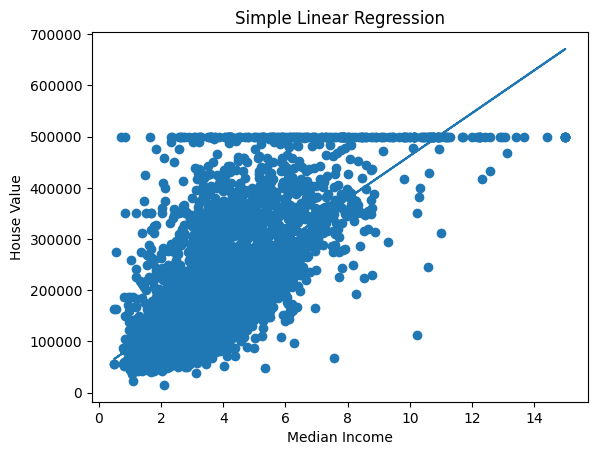

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_simple)
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Simple Linear Regression")
plt.show()

In [ ]:
X_multi = df[['median_income', 'housing_median_age', 'total_rooms']]
y = df['median_house_value']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_multi = model_multi.predict(X_test)

In [ ]:
mae_multi = mean_absolute_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("Multiple Model:")
print("MAE:", mae_multi)
print("RMSE:", rmse_multi)
print("R2:", r2_multi)

Multiple Model:
MAE: 60939.7973070972
RMSE: 81545.51916020575
R2: 0.5137415878339668


In [ ]:
print("Intercept:", model_multi.intercept_)
print("Coefficients:", model_multi.coef_)

Intercept: -23739.133323143848
Coefficients: [4.24400807e+04 1.95931467e+03 3.82479442e+00]


Markdown
### Accuracy Comparison

The Multiple Linear Regression model performed better than the Simple Linear Regression model.

- MAE is lower in the multiple model → better accuracy  
- RMSE is lower → fewer large errors  
- R² score is higher → better fit  

Thus, the multiple model gives more accurate predictions.

### Did adding more features improve the model?

Yes, adding more features improved the model performance.

This is because house prices depend on multiple factors like income, age of house, and number of rooms. Using more relevant features helps the model understand the data better and reduces prediction errors.

### Improving the Model

The model can be further improved by adding more relevant features such as:

- Location (very important for house prices)
- Ocean proximity (available in dataset but needs encoding)
- Population in the area

These additional features can help the model capture more real-world factors and improve accuracy.

### Conclusion

In this project, we applied both Simple and Multiple Linear Regression on the California Housing dataset.

The Simple Linear Regression model used only one feature and gave basic predictions, while the Multiple Linear Regression model used multiple features and provided more accurate results.

The evaluation metrics (MAE, RMSE, and R² score) showed that the multiple model performed better than the simple model.

Thus, we conclude that using multiple relevant features improves the performance of the regression model.
